# Notebook 8 - Distribution Analysis

Dataset: `healthcare_dataset.csv`



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

df = pd.read_csv('healthcare_dataset.csv')
df['Date of Admission'] = pd.to_datetime(df['Date of Admission'])
df['Discharge Date'] = pd.to_datetime(df['Discharge Date'])
df['Length of Stay'] = (df['Discharge Date'] - df['Date of Admission']).dt.days
df['Billing Amount Cleaned'] = df['Billing Amount'].abs()
df.shape

(55500, 17)

## 1. Normal Distribution

A normal distribution is symmetric and bell-shaped, with the mean, median, and mode all equal and located at the center. Roughly 68% of values fall within one standard deviation of the mean, 95% within two, and 99.7% within three. Many statistical methods assume normality, so checking for it is a common first step in distribution analysis.

## 2. Uniform Distribution

A uniform distribution has roughly equal probability across all values in its range, producing a flat histogram rather than a peak. There is no strong central tendency; every value is about as likely as any other.

## 3. Skewness

Skewness measures the asymmetry of a distribution.

- **Symmetric distribution**: skewness close to 0, left and right sides of the distribution mirror each other, mean approximately equals median
- **Right-skewed (positive skew)**: a long tail extends to the right, mean is pulled higher than the median
- **Left-skewed (negative skew)**: a long tail extends to the left, mean is pulled lower than the median

## 4. Kurtosis

Kurtosis measures the "tailedness" of a distribution relative to a normal distribution.

- **Mesokurtic**: kurtosis near 0 (excess kurtosis), tail behavior similar to a normal distribution
- **Leptokurtic**: kurtosis greater than 0, heavier tails and a sharper peak, more prone to extreme values
- **Platykurtic**: kurtosis less than 0, lighter tails and a flatter peak, fewer extreme values

## 5. Selecting Features for Analysis

`Age`, `Billing Amount Cleaned`, and `Length of Stay` are continuous measured variables and are the focus of this analysis. `Room Number` is an identifier rather than a measured quantity and is excluded from distribution analysis.

In [2]:
numeric_cols = ['Age', 'Billing Amount Cleaned', 'Length of Stay']
df[numeric_cols].describe()

,Age,Billing Amount Cleaned,Length of Stay
count,55500.000000,55500.000000,55500.000000
mean,51.539459,25541.259324,15.509009
std,19.602454,14207.961646,8.659600
min,13.000000,9.238787,1.000000
25%,35.000000,13241.224652,8.000000
50%,52.000000,25538.069376,15.000000
75%,68.000000,37820.508436,23.000000
max,89.000000,52764.276736,30.000000


## 6. Summary Statistics: Center, Spread, Skewness, Kurtosis

In [3]:
summary = pd.DataFrame(index=numeric_cols)
summary['mean'] = df[numeric_cols].mean()
summary['median'] = df[numeric_cols].median()
summary['mode'] = df[numeric_cols].mode().iloc[0]
summary['std'] = df[numeric_cols].std()
summary['variance'] = df[numeric_cols].var()
summary['range'] = df[numeric_cols].max() - df[numeric_cols].min()
summary['skewness'] = df[numeric_cols].skew()
summary['kurtosis'] = df[numeric_cols].kurt()
summary

,mean,median,mode,std,variance,range,skewness,kurtosis
Age,51.539459,52.000000,38.000000,19.602454,3.842562e+02,76.000000,-0.005735,-1.185576
Billing Amount Cleaned,25541.259324,25538.069376,26.112523,14207.961646,2.018662e+08,52755.037949,-0.000062,-1.192033
Length of Stay,15.509009,15.000000,21.000000,8.659600,7.498868e+01,29.000000,0.001886,-1.205098


## 7. Age Distribution

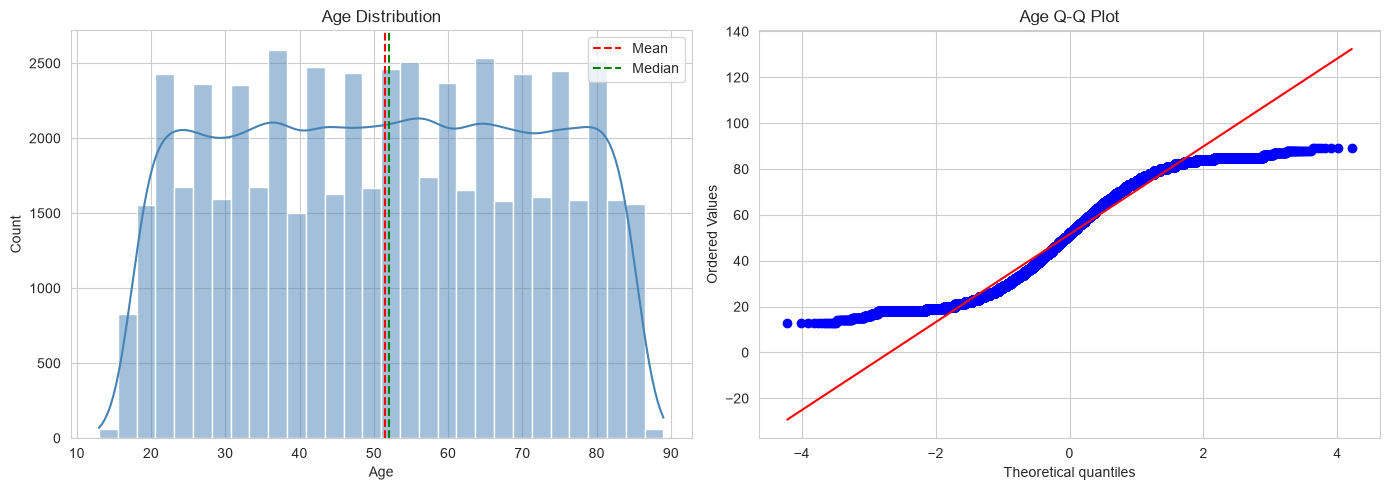

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df['Age'], kde=True, bins=30, ax=axes[0], color='steelblue')
axes[0].axvline(df['Age'].mean(), color='red', linestyle='--', label='Mean')
axes[0].axvline(df['Age'].median(), color='green', linestyle='--', label='Median')
axes[0].legend()
axes[0].set_title('Age Distribution')

stats.probplot(df['Age'], dist='norm', plot=axes[1])
axes[1].set_title('Age Q-Q Plot')
plt.tight_layout()
plt.show()

**Age - Interpretation:**

- **Shape:** approximately flat across the adult range rather than a single sharp peak, closer to a uniform-like spread than a classic bell curve
- **Center:** mean and median are close to each other, consistent with low skewness
- **Spread:** wide range covering the full adult lifespan present in the data
- **Skewness:** value near 0 indicates a roughly symmetric distribution
- **Kurtosis:** negative, indicating a platykurtic shape with lighter tails and a flatter peak than a normal distribution, consistent with the near-uniform spread
- **Outliers:** Notebook 7 found none by IQR or Z-score; the histogram and Q-Q plot confirm no extreme tail behavior

## 8. Billing Amount Distribution

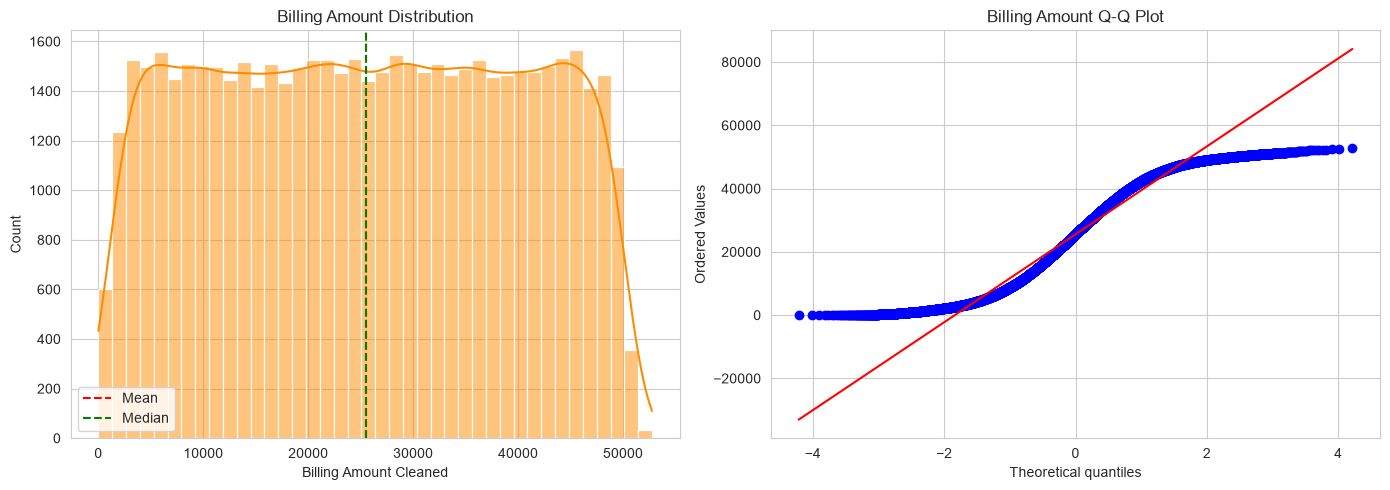

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df['Billing Amount Cleaned'], kde=True, bins=40, ax=axes[0], color='darkorange')
axes[0].axvline(df['Billing Amount Cleaned'].mean(), color='red', linestyle='--', label='Mean')
axes[0].axvline(df['Billing Amount Cleaned'].median(), color='green', linestyle='--', label='Median')
axes[0].legend()
axes[0].set_title('Billing Amount Distribution')

stats.probplot(df['Billing Amount Cleaned'], dist='norm', plot=axes[1])
axes[1].set_title('Billing Amount Q-Q Plot')
plt.tight_layout()
plt.show()

In [6]:
skew_billing = df['Billing Amount Cleaned'].skew()
kurt_billing = df['Billing Amount Cleaned'].kurt()
print(f"Skewness: {skew_billing:.4f}")
print(f"Kurtosis: {kurt_billing:.4f}")

Skewness: -0.0001
Kurtosis: -1.1920


**Billing Amount - Interpretation:**

- **Shape:** close to symmetric across most of the range, with the histogram spread fairly evenly rather than piled up at one end
- **Center:** mean and median are close, matching the low skewness value
- **Spread:** wide, covering roughly 0 to over 50,000, with a large standard deviation relative to comparable clinical measures
- **Skewness:** value near 0 indicates near-symmetric behavior rather than the strong right skew often expected in billing or financial data
- **Kurtosis:** negative, indicating a platykurtic shape with lighter tails and a flatter peak than a normal distribution
- **Outliers:** consistent with Notebook 7, some high values extend beyond the IQR upper bound, but they are not extreme enough to create heavy tails despite the flatter overall shape

## 9. Length of Stay Distribution

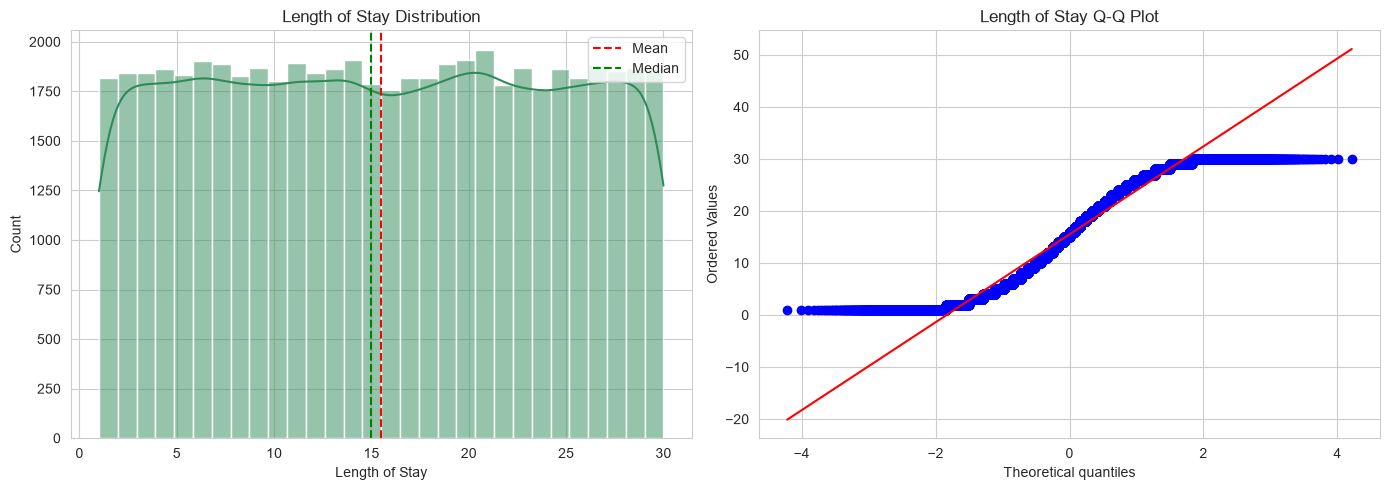

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df['Length of Stay'], kde=True, bins=30, ax=axes[0], color='seagreen')
axes[0].axvline(df['Length of Stay'].mean(), color='red', linestyle='--', label='Mean')
axes[0].axvline(df['Length of Stay'].median(), color='green', linestyle='--', label='Median')
axes[0].legend()
axes[0].set_title('Length of Stay Distribution')

stats.probplot(df['Length of Stay'], dist='norm', plot=axes[1])
axes[1].set_title('Length of Stay Q-Q Plot')
plt.tight_layout()
plt.show()

In [8]:
skew_los = df['Length of Stay'].skew()
kurt_los = df['Length of Stay'].kurt()
print(f"Skewness: {skew_los:.4f}")
print(f"Kurtosis: {kurt_los:.4f}")

Skewness: 0.0019
Kurtosis: -1.2051


**Length of Stay - Interpretation:**

- **Shape:** fairly even spread across its bounded range of admission durations, without a single dominant peak
- **Center:** mean and median are close together
- **Spread:** bounded between the minimum and maximum stay lengths present in the data, moderate standard deviation
- **Skewness:** value near 0 suggests a roughly symmetric distribution rather than the right skew typically expected for stay-duration data
- **Kurtosis:** negative, indicating a platykurtic shape with lighter tails and a flatter peak than a normal distribution
- **Outliers:** Notebook 7 identified a small number of long-stay records above the IQR upper bound; these are retained as plausible values and do not dominate the shape of the distribution

## 10. Distribution Shape Comparison

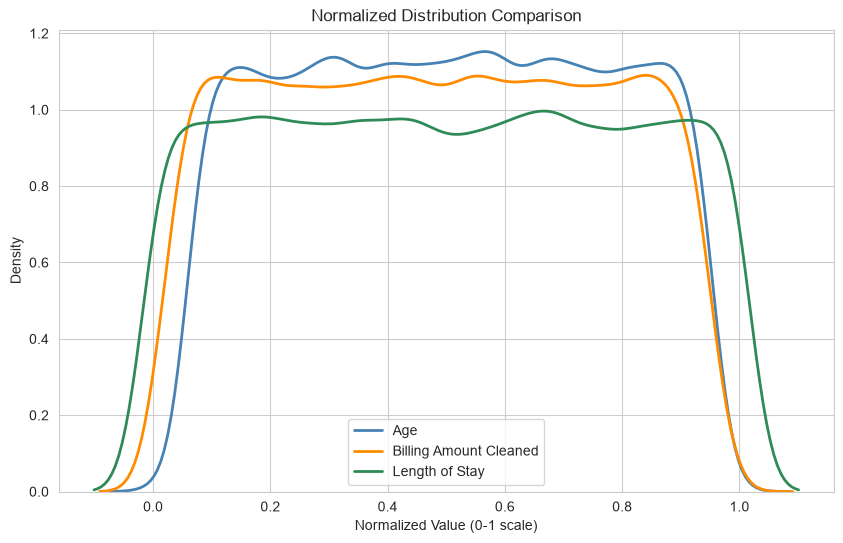

In [9]:
fig, ax = plt.subplots(figsize=(10, 6))
for col, color in zip(numeric_cols, ['steelblue', 'darkorange', 'seagreen']):
    normalized = (df[col] - df[col].min()) / (df[col].max() - df[col].min())
    sns.kdeplot(normalized, label=col, ax=ax, color=color, linewidth=2)
ax.set_title('Normalized Distribution Comparison')
ax.set_xlabel('Normalized Value (0-1 scale)')
ax.legend()
plt.show()

In [10]:
comparison = summary[['skewness', 'kurtosis']].copy()
comparison['skew_category'] = comparison['skewness'].apply(
    lambda x: 'Symmetric' if abs(x) < 0.5 else ('Right-Skewed' if x > 0 else 'Left-Skewed')
)
comparison['kurtosis_category'] = comparison['kurtosis'].apply(
    lambda x: 'Mesokurtic' if abs(x) < 0.5 else ('Leptokurtic' if x > 0 else 'Platykurtic')
)
comparison

,skewness,kurtosis,skew_category,kurtosis_category
Age,-0.005735,-1.185576,Symmetric,Platykurtic
Billing Amount Cleaned,-0.000062,-1.192033,Symmetric,Platykurtic
Length of Stay,0.001886,-1.205098,Symmetric,Platykurtic


## 11. Statistical Normality Check

The Shapiro-Wilk test formally checks whether a sample is likely drawn from a normal distribution. Given the large sample size, a random subsample is used since the test is highly sensitive to sample size and would reject normality for almost any large real-world dataset.

In [11]:
np.random.seed(42)
normality_results = {}
for col in numeric_cols:
    sample = df[col].sample(n=min(5000, len(df)), random_state=42)
    stat, p_value = stats.shapiro(sample)
    normality_results[col] = {
        'shapiro_stat': stat,
        'p_value': p_value,
        'likely_normal': p_value > 0.05
    }
pd.DataFrame(normality_results).T

,shapiro_stat,p_value,likely_normal
Age,0.956877,0.0,False
Billing Amount Cleaned,0.960021,0.0,False
Length of Stay,0.952895,0.0,False
